# Baseline Isolation Forest — IEEE-CIS Fraud Detection

**The Outliers** — Women in Mathematics Directed Research Program (Fall 2026)

## Objective

Load the IEEE-CIS Fraud Detection dataset, explore it deeply, and build a baseline
`scikit-learn` **Isolation Forest** model — entirely unsupervised.


In [1]:
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import umap
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RNG_SEED = 42
np.random.seed(RNG_SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100


/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DATA_DIR = "../../data/ieee-fraud-detection"

t0 = time.perf_counter()
tx = pd.read_csv(f"{DATA_DIR}/train_transaction.csv")
idt = pd.read_csv(f"{DATA_DIR}/train_identity.csv")
df = tx.merge(idt, on="TransactionID", how="left")
print(f"Loaded + merged in {time.perf_counter() - t0:.1f}s")
print(f"Merged shape: {df.shape}")


Loaded + merged in 11.6s
Merged shape: (590540, 434)


# Part 1: Data Exploration

## 1. Dataset — Initial Checks

In [3]:
print("Shape:", df.shape)
df.dtypes.value_counts()


Shape: (590540, 434)


float64    399
str         31
int64        4
Name: count, dtype: int64

In [4]:
df[["TransactionAmt", "card1", "card2", "card3", "card5"]].describe()


,TransactionAmt,card1,card2,card3,card5
count,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000
mean,135.027176,9898.734658,362.555488,153.194925,199.278897
std,239.162522,4901.170153,157.793246,11.336444,41.244453
min,0.251000,1000.000000,100.000000,100.000000,100.000000
25%,43.321000,6019.000000,214.000000,150.000000,166.000000
50%,68.769000,9678.000000,361.000000,150.000000,226.000000
75%,125.000000,14184.000000,512.000000,150.000000,226.000000
max,31937.391000,18396.000000,600.000000,231.000000,237.000000


In [5]:
fraud_counts = df["isFraud"].value_counts()
fraud_pct = df["isFraud"].mean() * 100
imbalance_ratio = fraud_counts[0] / fraud_counts[1]

print(fraud_counts)
print(f"\nFraud rate: {fraud_pct:.3f}%")
print(f"Imbalance ratio (non-fraud : fraud): {imbalance_ratio:.1f} : 1")


isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud rate: 3.499%
Imbalance ratio (non-fraud : fraud): 27.6 : 1


**Raw / interpretable features** include `TransactionAmt`, `ProductCD`, card-related
columns (`card1`-`card6`), address/email/device columns, the `C`/`D`/`M` columns, and
the `id_*` identity columns.

**Anonymized features** are `V1`-`V339` — engineered by the competition host with no
disclosed meaning.


In [6]:
v_cols = [c for c in df.columns if c.startswith("V")]
raw_cols = [c for c in df.columns if c not in v_cols and c not in ("TransactionID", "isFraud")]
print(f"Anonymized V columns: {len(v_cols)}")
print(f"Raw / interpretable columns: {len(raw_cols)}")


Anonymized V columns: 339
Raw / interpretable columns: 93


## 2. Class Imbalance

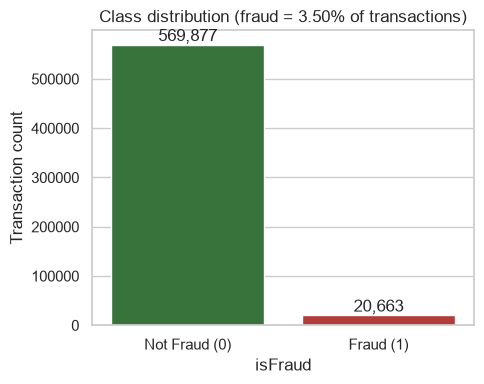

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=fraud_counts.index.astype(str), y=fraud_counts.values, ax=ax,
            hue=fraud_counts.index.astype(str), palette=["#2E7D32", "#C62828"], legend=False)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Not Fraud (0)", "Fraud (1)"])
ax.set_ylabel("Transaction count")
ax.set_title(f"Class distribution (fraud = {fraud_pct:.2f}% of transactions)")
for i, v in enumerate(fraud_counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()


**Findings:** Fraud is rare — about 3.5% of transactions are fraudulent, a roughly
27:1 imbalance. This has a direct consequence for Part 3: ranking-based metrics
(ROC-AUC, precision-recall AUC, precision at a fixed review budget) are appropriate;
raw accuracy would be meaningless since labeling everything "not fraud" already
scores ~96.5%. It also means the top-K anomalies inspected in Part 3 should contain
far more fraud than the base rate if Isolation Forest is picking up real signal.


## 3. Transaction Amount Distribution

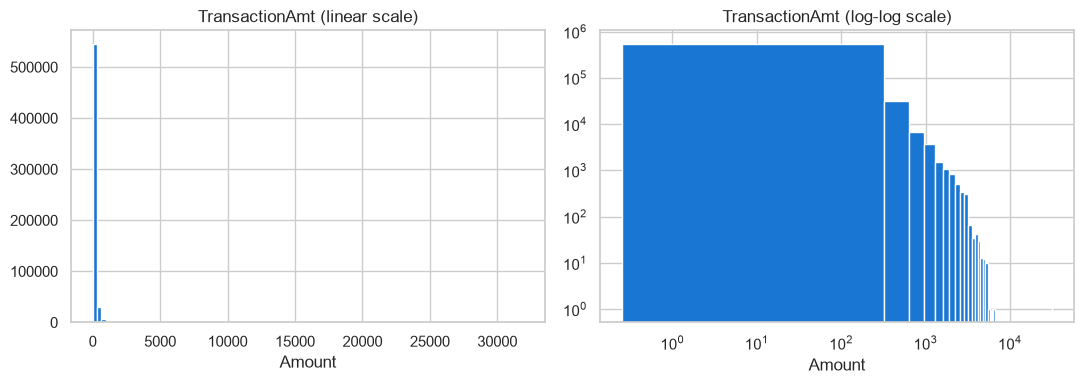

count    590540.000000
mean        135.027176
std         239.162522
min           0.251000
25%          43.321000
50%          68.769000
75%         125.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["TransactionAmt"], bins=100, color="#1976D2")
axes[0].set_title("TransactionAmt (linear scale)")
axes[0].set_xlabel("Amount")

axes[1].hist(df["TransactionAmt"], bins=100, color="#1976D2")
axes[1].set_yscale("log")
axes[1].set_xscale("log")
axes[1].set_title("TransactionAmt (log-log scale)")
axes[1].set_xlabel("Amount")
plt.tight_layout()
plt.show()

df["TransactionAmt"].describe()


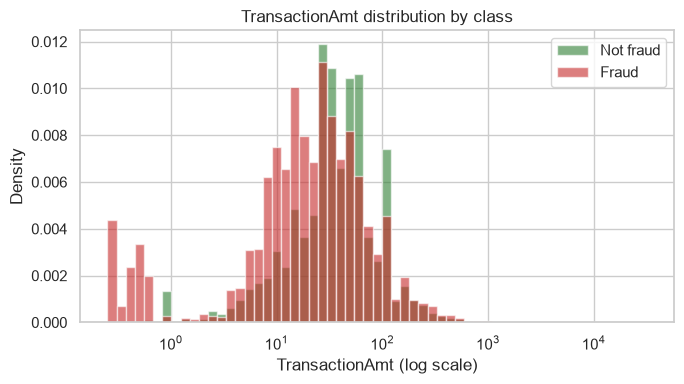

Fraud mean/median amt:   149.24 / 75.0
Non-fraud mean/median amt: 134.51 / 68.5


In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.logspace(np.log10(df["TransactionAmt"].min()), np.log10(df["TransactionAmt"].max()), 60)
ax.hist(df.loc[df.isFraud == 0, "TransactionAmt"], bins=bins, alpha=0.6, label="Not fraud", color="#2E7D32", density=True)
ax.hist(df.loc[df.isFraud == 1, "TransactionAmt"], bins=bins, alpha=0.6, label="Fraud", color="#C62828", density=True)
ax.set_xscale("log")
ax.set_xlabel("TransactionAmt (log scale)")
ax.set_ylabel("Density")
ax.set_title("TransactionAmt distribution by class")
ax.legend()
plt.tight_layout()
plt.show()

print("Fraud mean/median amt:  ", df.loc[df.isFraud == 1, "TransactionAmt"].mean().round(2),
      "/", df.loc[df.isFraud == 1, "TransactionAmt"].median().round(2))
print("Non-fraud mean/median amt:", df.loc[df.isFraud == 0, "TransactionAmt"].mean().round(2),
      "/", df.loc[df.isFraud == 0, "TransactionAmt"].median().round(2))


**Findings:** `TransactionAmt` is heavily right-skewed (mean ≈ \$135 but a max above
\$31,900), which is why the log-scale view is necessary to see the shape at all. Fraud
amounts run slightly *higher* on average than non-fraud (mean \$149 vs. \$135; median
\$75 vs. \$68.50), but the two distributions overlap substantially — amount alone is a
weak discriminator, consistent with fraudsters not needing unusually large purchases to
be profitable.


## 4. Categorical Features

> **Leakage note:** fraud rate by category below is computed purely for exploration.
> It is never fed back into the model as a feature in Part 2.


In [10]:
for col in ["ProductCD", "card4", "card6"]:
    summary = df.groupby(col)["isFraud"].agg(["mean", "count"]).rename(columns={"mean": "fraud_rate"})
    summary["fraud_rate_pct"] = (summary["fraud_rate"] * 100).round(2)
    print(f"--- {col} ---")
    print(summary.sort_values("fraud_rate", ascending=False))
    print()


--- ProductCD ---
           fraud_rate   count  fraud_rate_pct
ProductCD                                    
C            0.116873   68519           11.69
S            0.058996   11628            5.90
H            0.047662   33024            4.77
R            0.037826   37699            3.78
W            0.020399  439670            2.04

--- card4 ---
                  fraud_rate   count  fraud_rate_pct
card4                                               
discover            0.077282    6651            7.73
visa                0.034756  384767            3.48
mastercard          0.034331  189217            3.43
american express    0.028698    8328            2.87

--- card6 ---
                 fraud_rate   count  fraud_rate_pct
card6                                              
credit             0.066785  148986            6.68
debit              0.024263  439938            2.43
charge card        0.000000      15            0.00
debit or credit    0.000000      30            0.00


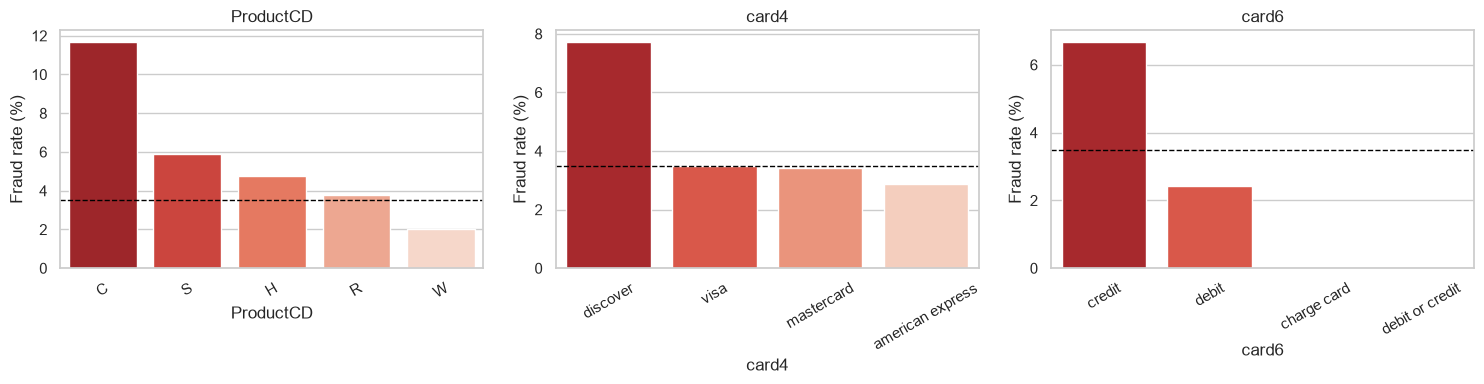

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["ProductCD", "card4", "card6"]):
    rates = df.groupby(col)["isFraud"].mean().sort_values(ascending=False) * 100
    sns.barplot(x=rates.index.astype(str), y=rates.values, ax=ax, hue=rates.index.astype(str),
                palette="Reds_r", legend=False)
    ax.axhline(fraud_pct, color="black", linestyle="--", linewidth=1, label="overall rate")
    ax.set_ylabel("Fraud rate (%)")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


**Findings:** category-level fraud rates vary a lot more than overall volume would
suggest. `ProductCD == "C"` has an 11.7% fraud rate versus the overall 3.5% baseline
(and versus 2.0% for the much larger `ProductCD == "W"` segment). `card4 == "discover"`
(7.7%) and `card6 == "credit"` (6.7% vs. 2.4% for debit) also run well above baseline.
These categories are rare relative to the dominant `W`/`visa`/`debit` segments, which is
exactly the kind of rarity Isolation Forest is designed to exploit — it's why the
baseline model encodes category *frequency* (Part 2) rather than discarding categoricals
entirely: rare categories should isolate faster.


## 5. Missing Values

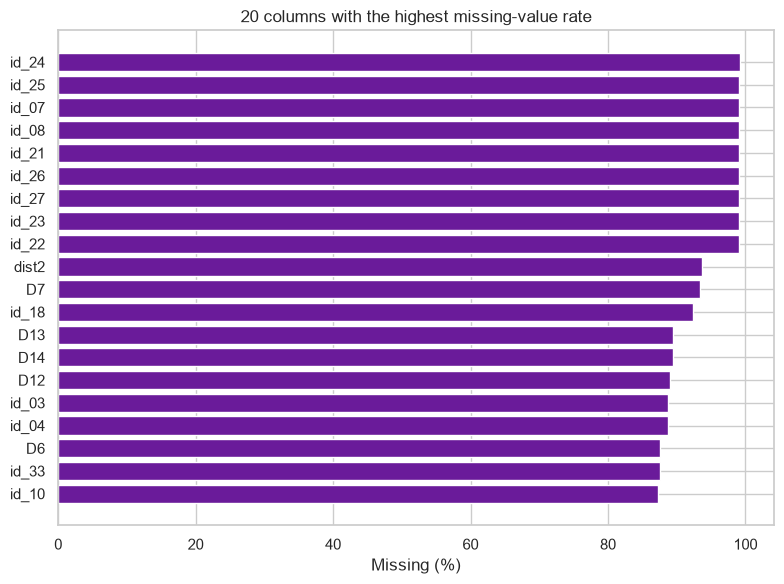

Columns with >90% missing: 12 / 434


In [12]:
missing_pct = df.isna().mean().sort_values(ascending=False) * 100
top20 = missing_pct.head(20)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top20.index[::-1], top20.values[::-1], color="#6A1B9A")
ax.set_xlabel("Missing (%)")
ax.set_title("20 columns with the highest missing-value rate")
plt.tight_layout()
plt.show()

n_over_90 = (missing_pct > 90).sum()
print(f"Columns with >90% missing: {n_over_90} / {df.shape[1]}")


In [13]:
row_missing_pct = df.isna().mean(axis=1)
print("Mean fraction of columns missing per row:")
print(f"  Fraud rows:     {row_missing_pct[df.isFraud == 1].mean():.3f}")
print(f"  Non-fraud rows: {row_missing_pct[df.isFraud == 0].mean():.3f}")

top_missing_cols = missing_pct.head(10).index.tolist()
comparison = pd.DataFrame({
    "missing_pct_overall": missing_pct[top_missing_cols],
    "missing_pct_fraud": [df.loc[df.isFraud == 1, c].isna().mean() * 100 for c in top_missing_cols],
    "missing_pct_nonfraud": [df.loc[df.isFraud == 0, c].isna().mean() * 100 for c in top_missing_cols],
})
comparison


Mean fraction of columns missing per row:
  Fraud rows:     0.373
  Non-fraud rows: 0.454


,missing_pct_overall,missing_pct_fraud,missing_pct_nonfraud
id_24,99.196159,98.054494,99.237555
id_25,99.130965,97.981900,99.172628
id_07,99.127070,97.938344,99.170172
id_08,99.127070,97.938344,99.170172
id_21,99.126393,97.938344,99.169470
id_26,99.125715,97.943183,99.168593
id_27,99.124699,97.938344,99.167715
id_23,99.124699,97.938344,99.167715
id_22,99.124699,97.938344,99.167715
dist2,93.628374,81.943571,94.052050


**Findings:** 12 columns (mostly `id_*` identity fields and `dist2`) are missing in
over 90% of rows and are dropped before modeling (Part 2). Missingness carry a
weak fraud signal: fraud rows are,
on average, slightly *more complete* than non-fraud rows (37% of columns missing vs.
45%)

## 6. Anonymized Features: V1–V339

(1) a correlation heatmap of a **randomly sampled** subset of `V` columns,
to see how redundant the block is without cherry-picking which columns to look at;
(2) each `V` column's correlation with `isFraud` to see which features are worth a closer look; and
(3) distribution/spread plots, split by class, for the features that come out most
correlated with fraud in step 2.

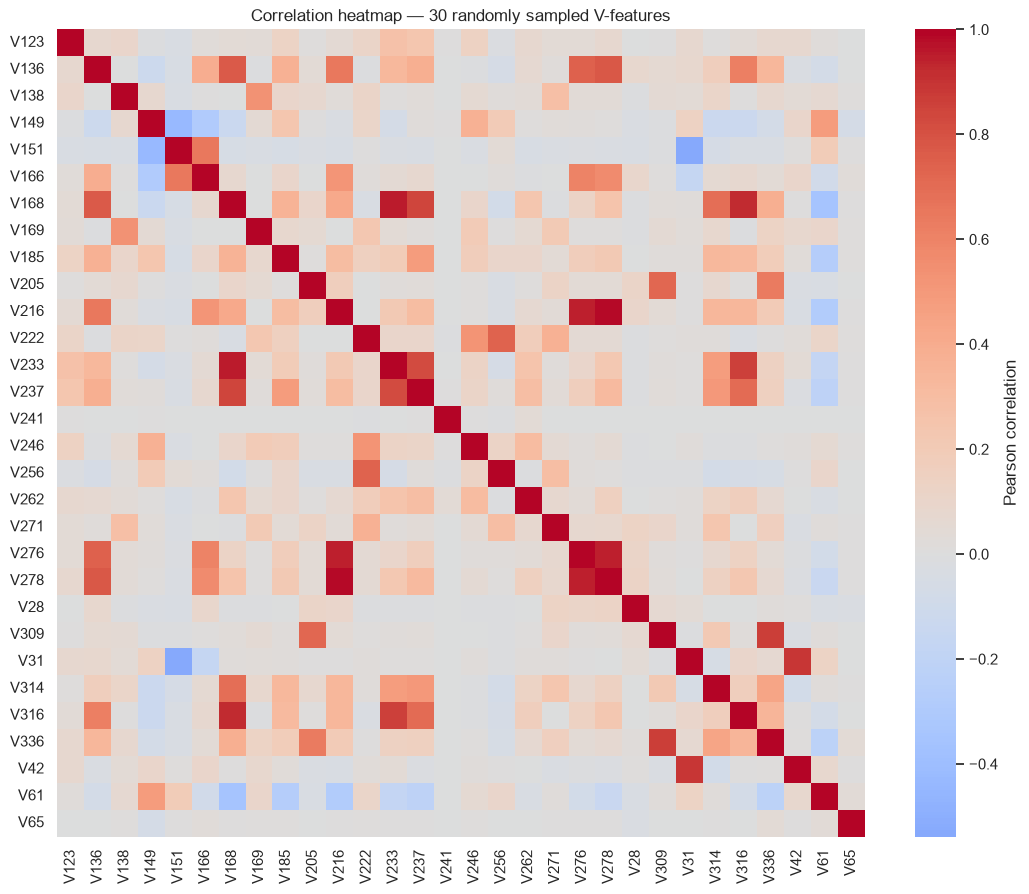

In [14]:
N_RANDOM_V = 30
rng_sample = np.random.default_rng(RNG_SEED)
random_v_cols = sorted(rng_sample.choice(v_cols, size=N_RANDOM_V, replace=False).tolist())

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(df[random_v_cols].corr(), cmap="coolwarm", center=0, ax=ax, square=True,
            cbar_kws={"label": "Pearson correlation"})
ax.set_title(f"Correlation heatmap — {N_RANDOM_V} randomly sampled V-features")
plt.tight_layout()
plt.show()


In [15]:
# EDA only: correlation with isFraud, used to decide what to look at next -- never fed
# back into Part 2 as a training feature.
fraud_corr = df[v_cols].corrwith(df["isFraud"])
fraud_corr = fraud_corr.reindex(fraud_corr.abs().sort_values(ascending=False).index)

print("Top 15 V-features by |correlation with isFraud|:")
fraud_corr.head(15)


Top 15 V-features by |correlation with isFraud|:


V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
V158    0.278066
V156    0.275952
V149    0.273282
V228    0.268861
V44     0.260376
dtype: float64

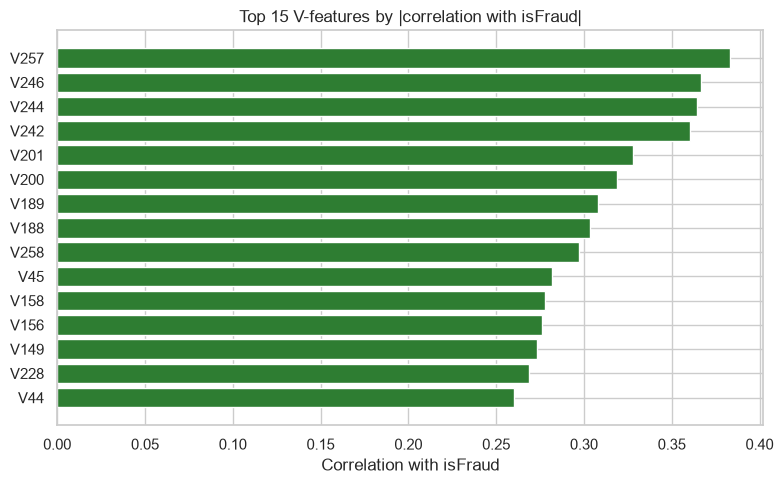

In [16]:
top15 = fraud_corr.head(15)
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#C62828" if v < 0 else "#2E7D32" for v in top15.values]
ax.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1])
ax.set_xlabel("Correlation with isFraud")
ax.set_title("Top 15 V-features by |correlation with isFraud|")
plt.tight_layout()
plt.show()


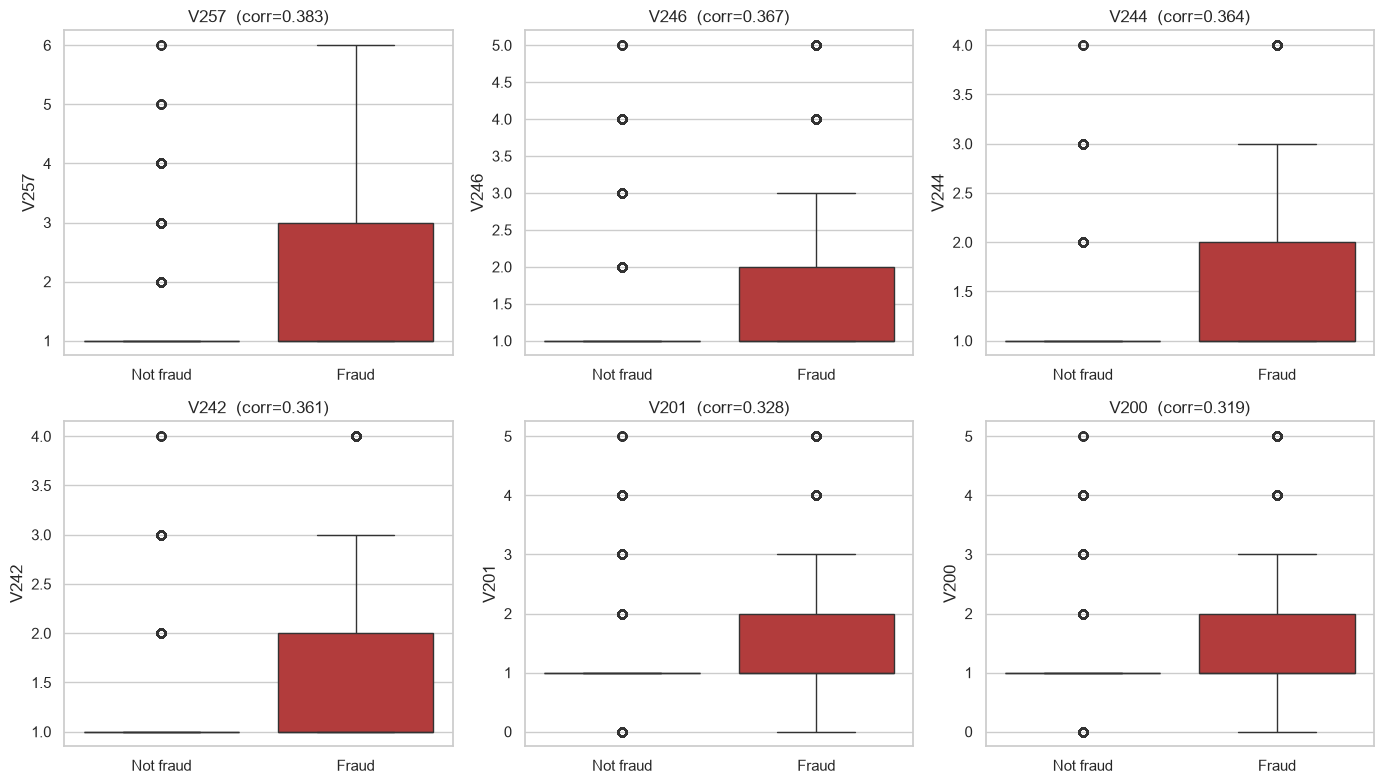

In [17]:
top_fraud_corr_cols = fraud_corr.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), top_fraud_corr_cols):
    plot_df = df[[col, "isFraud"]].dropna()
    lo, hi = plot_df[col].quantile([0.01, 0.99])
    plot_df = plot_df[plot_df[col].between(lo, hi)]
    sns.boxplot(data=plot_df, x="isFraud", y=col, ax=ax, hue="isFraud",
                palette={0: "#2E7D32", 1: "#C62828"}, legend=False)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Not fraud", "Fraud"])
    ax.set_xlabel("")
    ax.set_title(f"{col}  (corr={fraud_corr[col]:.3f})")
plt.tight_layout()
plt.show()


**Findings:** the randomly sampled correlation heatmap shows the `V` block is *not*
uniformly redundant — most of the 30×30 grid is close to zero (grey) — but a handful of
tight clusters stand out: `V276`/`V278` run close to perfectly correlated (~0.9+), with
`V168`, `V216`, `V233`, `V237`, `V314`, and `V316` each forming their own visible
same-direction blocks, while `V149`, `V151`, `V166`, and `V31` form a distinct
*negatively* correlated cluster (down to roughly -0.5). So redundancy is real but
concentrated in specific feature groups rather than dataset-wide — consistent with
these columns being aggregates of the same underlying signal over different windows.

The correlation-with-fraud ranking is dominated by a tight group, all **positively**
correlated (no negative entries make the top 15): `V257` (0.383), `V246` (0.367),
`V244` (0.364), `V242` (0.361), `V201` (0.328), `V200` (0.319), `V189` (0.308),
`V188` (0.304), `V258` (0.297), `V45` (0.282), `V158` (0.278), `V156` (0.276),
`V149` (0.273), `V228` (0.269), `V44` (0.260) — noticeably stronger correlations than
any single raw/interpretable feature explored so far (`TransactionAmt` barely separates
the classes at all by comparison).

The box plots for the top 6 (`V257`, `V246`, `V244`, `V242`, `V201`, `V200`) make the
pattern vivid and consistent across all six: for **non-fraud** transactions the box is
collapsed to a flat line at 1 (the 25th-75th percentile is exactly 1, with only a sparse
scatter of outlier dots reaching 4-6), while for **fraud** the box visibly widens — the
median shifts to 1-2 and the interquartile range reaches roughly 2-3. In other words,
most legitimate transactions show exactly the baseline value on these columns, while
fraudulent ones show meaningfully higher and more variable values.

## 7. Exploration Write-Up

**Summary of findings**

- Fraud is rare (3.5%, ~27:1 imbalance), so the model will be judged on ranking metrics
  (AUC, precision at a fixed budget) rather than accuracy.
- `TransactionAmt` is heavily right-skewed; fraud trends slightly higher in amount but
  overlaps heavily with non-fraud — a weak signal on its own.
- Categorical rarity matters more than category identity: `ProductCD == C`,
  `card4 == discover`, and `card6 == credit` all show fraud rates 2-3x the baseline
  despite being minority segments.
- Missingness is informative but counterintuitive — fraud rows tend to be *more* complete
  than non-fraud rows, not less. 
- The anonymized `V` block is redundant in pockets rather than uniformly — the randomly
  sampled heatmap shows a few tight clusters (e.g. `V276`/`V278` near-perfectly
  correlated, plus a `V149`/`V151`/`V166`/`V31` cluster that's *negatively* correlated)
  against a mostly-independent background. More importantly, a group of ~15 V-features
  (`V257`, `V246`, `V244`, `V242`, `V201`, `V200`, `V189`, `V188`, `V258`, `V45`, `V158`,
  `V156`, `V149`, `V228`, `V44`) correlate with `isFraud` far more strongly (0.26-0.38)
  than any raw/interpretable feature explored so far, and the box plots show why: these
  columns sit at a flat baseline value of 1 for almost all non-fraud transactions, while
  fraud transactions show a visibly wider, higher spread (median 1-2, IQR up to 2-3).
  This is the clearest, most interpretable signal found in the entire exploration.


# Part 2: Training Plan

Proposing three different training strategies, the comparison is meant to
show how much feature engineering actually matters for Isolation Forest on this
dataset, rather than committing to one pipeline up front.

**Shared data preparation**

- Exclude `TransactionID` (identifier), `isFraud` (label), `TransactionDT` (timestamp).
- Drop columns missing in more than 90% of rows (same threshold as the first attempt).
- Everything else — which columns are kept, how they're encoded — is decided
  separately by each strategy below.

**Three training strategies**

1. **Full high-dimensional set, no reduction** — use every remaining column with only
   the minimal encoding needed to make it numeric. No feature selection, no
   dimensionality reduction.
2. **Categorical features only, one-hot encoded** — Part 1 §4 showed some categories
   have a large effect on fraud rate; this strategy trains purely on one-hot-encoded
   categorical columns, with no numeric columns at all.
3. **Correlation-based reduction across engineered feature families** — from the `V`,
   `C`, `D`, `M`, and `id_` columns, keep only those most correlated with `isFraud`
   (EDA-only use of the label, exactly as in Part 1 §6), and train on that reduced set.

**Fixed training protocol (identical for all three strategies)**

- Training sample size is fixed at **n=256** — the same 256 randomly sampled
  transactions are used to fit all three models, so the only thing varying across
  strategies is the feature set, not the amount of training data.
- Sample-size scalability and runtime cost are out of scope here (see the first
  attempt's Part 4 for that kind of analysis) — the focus is purely on comparing
  feature/training strategies.

**Anomaly score convention**

`scikit-learn`'s `IsolationForest.score_samples` returns the *negative* of the anomaly
score defined in the original Isolation Forest paper (Liu, Ting & Zhou, 2008), where
the paper's score `s(x, n)` lies in `(0, 1]`: **closer to 1 means more anomalous,
closer to 0 means more normal**. We recover the paper's convention with
`anomaly_score = -model.score_samples(X)` and use that score everywhere below,
including for ROC-AUC — where, as always, a higher AUC means the model ranks actual
fraud as more anomalous.


In [18]:
def paper_anomaly_score(model, X):
    """Original Isolation Forest paper's s(x, n) in (0, 1]: closer to 1 = more
    anomalous, closer to 0 = more normal. sklearn's score_samples is the negative of
    this, so we flip the sign."""
    return -model.score_samples(X)


EXCLUDE_COLS = ["TransactionID", "isFraud", "TransactionDT"]
MISSING_DROP_THRESHOLD = 0.90

missing_pct_all = df.isna().mean()
cols_to_drop_missing = missing_pct_all[missing_pct_all > MISSING_DROP_THRESHOLD].index.tolist()
print(f"Dropping {len(cols_to_drop_missing)} columns with >{MISSING_DROP_THRESHOLD:.0%} missing")

work = df.drop(columns=EXCLUDE_COLS + cols_to_drop_missing)
y = df["isFraud"].copy()  # withheld from training everywhere below; evaluation only

TRAIN_SAMPLE_SIZE = 256
rng_train = np.random.default_rng(RNG_SEED)
train_idx = rng_train.choice(df.index, size=TRAIN_SAMPLE_SIZE, replace=False)
print(f"Fixed training sample: {TRAIN_SAMPLE_SIZE} rows (seed={RNG_SEED}), "
      f"reused across all three strategies")


Dropping 12 columns with >90% missing
Fixed training sample: 256 rows (seed=42), reused across all three strategies


## Strategy 1: Full High-Dimensional Feature Set (No Reduction)

Use every column that survived the missing-value drop, with the minimum possible
encoding to make the data numeric: median imputation for numeric columns, and simple
ordinal (label) encoding for categorical columns — no one-hot, no feature selection,
no dimensionality reduction. This is deliberately the "naive, throw everything in"
baseline.


In [19]:
numeric_cols_s1 = [c for c in work.columns if pd.api.types.is_numeric_dtype(work[c])]
categorical_cols_s1 = [c for c in work.columns if c not in numeric_cols_s1]

X1 = work.copy()
X1[numeric_cols_s1] = X1[numeric_cols_s1].apply(lambda s: s.fillna(s.median()))
for col in categorical_cols_s1:
    X1[col] = pd.factorize(X1[col].fillna("missing"))[0]

assert X1.isna().sum().sum() == 0
print(f"Strategy 1 feature matrix: {X1.shape} "
      f"({len(numeric_cols_s1)} numeric, {len(categorical_cols_s1)} ordinal-encoded categorical)")


Strategy 1 feature matrix: (590540, 419) (390 numeric, 29 ordinal-encoded categorical)


In [20]:
model_s1 = IsolationForest(random_state=RNG_SEED)  # default contamination, no tuning
model_s1.fit(X1.loc[train_idx])

scores_s1 = paper_anomaly_score(model_s1, X1)
auc_s1 = roc_auc_score(y, scores_s1)
print(f"Strategy 1 -- features: {X1.shape[1]}, AUC: {auc_s1:.4f}")
print(f"Anomaly score range: [{scores_s1.min():.3f}, {scores_s1.max():.3f}]")


Strategy 1 -- features: 419, AUC: 0.7719
Anomaly score range: [0.310, 0.760]


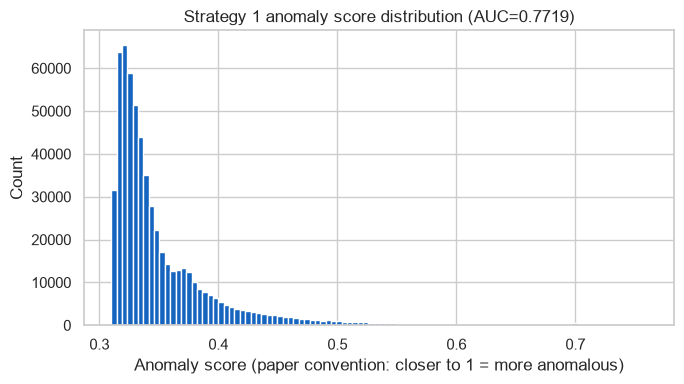

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(scores_s1, bins=100, color="#1565C0")
ax.set_xlabel("Anomaly score (paper convention: closer to 1 = more anomalous)")
ax.set_ylabel("Count")
ax.set_title(f"Strategy 1 anomaly score distribution (AUC={auc_s1:.4f})")
plt.tight_layout()
plt.show()


**Findings:** Strategy 1 scores **AUC = 0.7719** — the highest of all three strategies,
despite being the most naive (419 features, just median imputation and ordinal
encoding, no selection at all). The anomaly score spans a wide range, [0.310, 0.760],
consistent with the model finding plenty of room to separate unusual points. Feeding in
every available dimension doesn't seem to hurt Isolation Forest here: because each tree
only needs an occasional useful split, more raw dimensions increase the odds that an
anomaly stands out on *some* axis, even if most of the 419 columns individually carry
little signal. This is a notably better result than the original heavily-engineered
baseline (~0.72-0.73 AUC), achieved with far less preprocessing effort.


## Strategy 2: Categorical Features Only (One-Hot Encoded)

Part 1 §4 showed some categories (`ProductCD == C`, `card4 == discover`,
`card6 == credit`) have a meaningfully higher fraud rate than the dataset average. This
strategy tests whether categorical information *alone* — with no numeric features at
all — is enough for Isolation Forest to rank fraud highly.

This uses the dataset's true categorical (text/object-dtype) columns, one-hot encoded.
High-cardinality text columns (`DeviceInfo` with ~1,800 unique values, email domains,
browser/OS/resolution strings) are excluded from one-hot encoding — one-hot blows up to
one column per category, which is a scale problem one-hot isn't suited for, not a
feature-reduction decision. Categorical columns with at most 15 unique values are kept.


In [22]:
MAX_ONEHOT_CARDINALITY = 15
categorical_cols_all = [c for c in work.columns if not pd.api.types.is_numeric_dtype(work[c])]
categorical_cols_s2 = [c for c in categorical_cols_all
                        if work[c].nunique(dropna=True) <= MAX_ONEHOT_CARDINALITY]
excluded_high_card = sorted(set(categorical_cols_all) - set(categorical_cols_s2))

print(f"Categorical columns available: {len(categorical_cols_all)}")
print(f"Kept for one-hot (<= {MAX_ONEHOT_CARDINALITY} categories): {len(categorical_cols_s2)}")
print(f"Excluded (too high cardinality for one-hot): {excluded_high_card}")


Categorical columns available: 29
Kept for one-hot (<= 15 categories): 23
Excluded (too high cardinality for one-hot): ['DeviceInfo', 'P_emaildomain', 'R_emaildomain', 'id_30', 'id_31', 'id_33']


In [23]:
cat_part_s2 = work[categorical_cols_s2].fillna("missing")
X2 = pd.get_dummies(cat_part_s2, prefix=categorical_cols_s2, dtype=float)

assert X2.isna().sum().sum() == 0
print(f"Strategy 2 feature matrix: {X2.shape} "
      f"(one-hot columns from {len(categorical_cols_s2)} categorical features)")


Strategy 2 feature matrix: (590540, 79) (one-hot columns from 23 categorical features)


In [24]:
model_s2 = IsolationForest(random_state=RNG_SEED)
model_s2.fit(X2.loc[train_idx])

scores_s2 = paper_anomaly_score(model_s2, X2)
auc_s2 = roc_auc_score(y, scores_s2)
print(f"Strategy 2 -- features: {X2.shape[1]}, AUC: {auc_s2:.4f}")
print(f"Anomaly score range: [{scores_s2.min():.3f}, {scores_s2.max():.3f}]")


Strategy 2 -- features: 79, AUC: 0.6732
Anomaly score range: [0.404, 0.676]


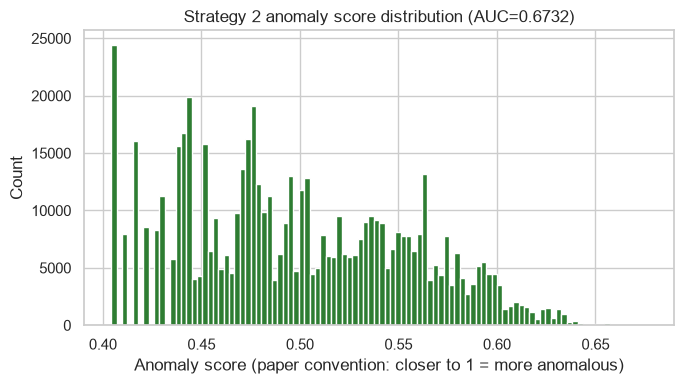

In [25]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(scores_s2, bins=100, color="#2E7D32")
ax.set_xlabel("Anomaly score (paper convention: closer to 1 = more anomalous)")
ax.set_ylabel("Count")
ax.set_title(f"Strategy 2 anomaly score distribution (AUC={auc_s2:.4f})")
plt.tight_layout()
plt.show()


**Findings:** Strategy 2 scores **AUC = 0.6732** — clearly the weakest of the three,
roughly 10 points of AUC below Strategy 1, though still well above random guessing
(0.5). This is despite using exactly the categories (`ProductCD`, `card4`, `card6`,
etc.) that Part 1 §4 showed have elevated fraud rates. The anomaly score range is also
the narrowest of the three, [0.404, 0.676] — one-hot categorical columns are all 0/1,
so there's a hard ceiling on how "extreme" any single point can look, which caps how
far Isolation Forest can separate anomalies. The takeaway: categorical rarity alone
*is* a real signal (the AUC is well above 0.5), but it isn't sufficient by itself —
numeric magnitude and spread information (amounts, the `V` features) is doing real
work in the other two strategies that pure categorical structure can't replace.


## Strategy 3: Correlation-Based Reduction Across V/C/D/M/id_ Features

From the engineered feature families — `V1`-`V339`, `C1`-`C14`, `D1`-`D15`, `M1`-`M9`,
and `id_01`-`id_38` — keep only the columns most correlated with `isFraud`, following
the same EDA-only correlation approach as Part 1 §6. `M` columns (`T`/`F`) are mapped
to `1`/`0`; categorical `id_` columns are label-encoded, purely so a Pearson
correlation can be computed — this is still an EDA-only use of the label to pick
features, never training on the label itself.


In [26]:
vcdm_id_cols = [c for c in work.columns if re.fullmatch(r"V\d+", c)
                 or re.fullmatch(r"C\d+", c)
                 or re.fullmatch(r"D\d+", c)
                 or re.fullmatch(r"M\d+", c)
                 or re.fullmatch(r"id_\d+", c)]
print(f"V/C/D/M/id_ columns available after missing-value drop: {len(vcdm_id_cols)}")


V/C/D/M/id_ columns available after missing-value drop: 404


In [ ]:
TOP_K_S3 = 30

numeric_for_corr = pd.DataFrame(index=work.index)
for col in vcdm_id_cols:
    s = work[col]
    if pd.api.types.is_numeric_dtype(s):
        numeric_for_corr[col] = s.fillna(s.median())
    elif col.startswith("M"):
        encoded = s.map({"T": 1, "F": 0})
        numeric_for_corr[col] = encoded.fillna(encoded.median())
    else:  # categorical id_ columns
        numeric_for_corr[col] = pd.factorize(s.fillna("missing"))[0]

# EDA-only use of the label to select features -- never fed into training itself.
fraud_corr_s3 = numeric_for_corr.corrwith(y)
fraud_corr_s3 = fraud_corr_s3.reindex(fraud_corr_s3.abs().sort_values(ascending=False).index)

top_cols_s3 = fraud_corr_s3.head(TOP_K_S3).index.tolist()
fraud_corr_s3.head(TOP_K_S3)


In [28]:
X3 = numeric_for_corr[top_cols_s3]

assert X3.isna().sum().sum() == 0
print(f"Strategy 3 feature matrix: {X3.shape}")


Strategy 3 feature matrix: (590540, 30)


In [29]:
model_s3 = IsolationForest(random_state=RNG_SEED)
model_s3.fit(X3.loc[train_idx])

scores_s3 = paper_anomaly_score(model_s3, X3)
auc_s3 = roc_auc_score(y, scores_s3)
print(f"Strategy 3 -- features: {X3.shape[1]}, AUC: {auc_s3:.4f}")
print(f"Anomaly score range: [{scores_s3.min():.3f}, {scores_s3.max():.3f}]")


Strategy 3 -- features: 30, AUC: 0.7235
Anomaly score range: [0.301, 0.852]


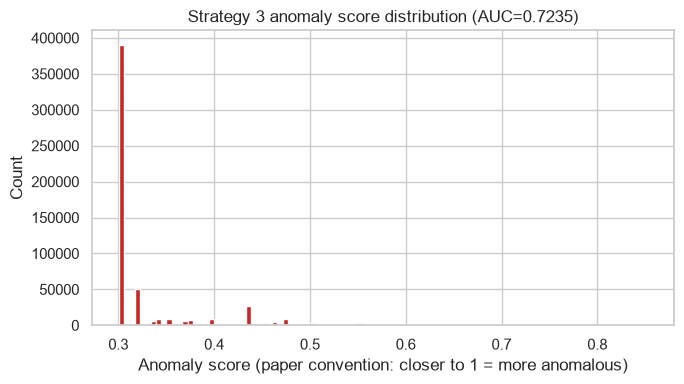

In [30]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(scores_s3, bins=100, color="#C62828")
ax.set_xlabel("Anomaly score (paper convention: closer to 1 = more anomalous)")
ax.set_ylabel("Count")
ax.set_title(f"Strategy 3 anomaly score distribution (AUC={auc_s3:.4f})")
plt.tight_layout()
plt.show()


**Findings:** Strategy 3 scores **AUC = 0.7235** with just **30 features** — between
Strategy 2 and Strategy 1, but much closer to Strategy 1's 0.7719 despite using about
14x fewer columns (30 vs. 419). The selected set is almost entirely `V`-features: 28 of
the top 30 are `V` columns, and only `id_35` and `id_17` break in from the `id_` family
— no `C`, `D`, or `M` column made the cut even though all four families were eligible.
Note also that these correlation values (e.g. `V257` at 0.280) come out systematically
*lower* than the same features' correlations in Part 1 §6 (`V257` at 0.383) — here,
missing values are median-imputed *before* computing the correlation, and that
imputation dilutes the apparent relationship (imputed rows contribute a constant value
instead of real variation). Even with that dilution, the selection still recovers most
of Strategy 1's signal from a much smaller, fully documented feature set — this looks
like the best efficiency tradeoff of the three.


## Strategy 4: Categorical + Correlation-Reduced Numeric Combined

Strategies 2 and 3 captured different kinds of signal — categorical rarity (one-hot,
79 columns) and numeric correlation with fraud (30 columns from `V`/`C`/`D`/`M`/`id_`)
— and neither was as strong alone as Strategy 1's full feature set. This strategy tests
whether the two are complementary: simply concatenate Strategy 2's one-hot matrix and
Strategy 3's correlation-selected matrix into one feature set and fit Isolation Forest
on the combination, using the same fixed n=256 training sample as every other strategy.


In [31]:
X4 = pd.concat([X2, X3], axis=1)

assert X4.isna().sum().sum() == 0
print(f"Strategy 4 feature matrix: {X4.shape} "
      f"(Strategy 2's {X2.shape[1]} one-hot + Strategy 3's {X3.shape[1]} correlation-selected)")


Strategy 4 feature matrix: (590540, 109) (Strategy 2's 79 one-hot + Strategy 3's 30 correlation-selected)


In [32]:
model_s4 = IsolationForest(random_state=RNG_SEED)
model_s4.fit(X4.loc[train_idx])

scores_s4 = paper_anomaly_score(model_s4, X4)
auc_s4 = roc_auc_score(y, scores_s4)
print(f"Strategy 4 -- features: {X4.shape[1]}, AUC: {auc_s4:.4f}")
print(f"Anomaly score range: [{scores_s4.min():.3f}, {scores_s4.max():.3f}]")


Strategy 4 -- features: 109, AUC: 0.7527
Anomaly score range: [0.388, 0.737]


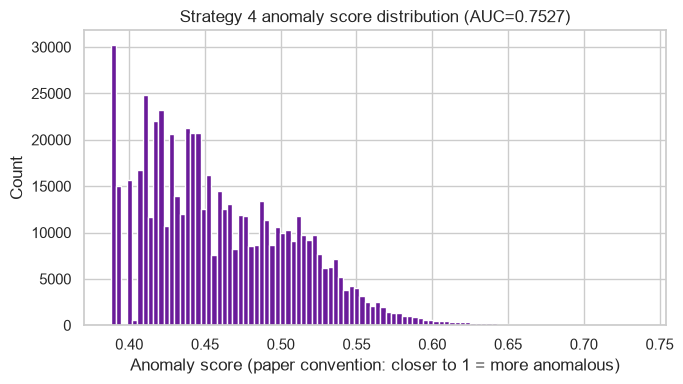

In [33]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(scores_s4, bins=100, color="#6A1B9A")
ax.set_xlabel("Anomaly score (paper convention: closer to 1 = more anomalous)")
ax.set_ylabel("Count")
ax.set_title(f"Strategy 4 anomaly score distribution (AUC={auc_s4:.4f})")
plt.tight_layout()
plt.show()


**Findings:** Strategy 4 scores **AUC = 0.7527** with **109 features** — and this
confirms the two signals are genuinely complementary rather than redundant: it beats
both Strategy 2 (0.6732) and Strategy 3 (0.7235) individually, by a clear margin in
both cases, not just splitting the difference. Combining categorical rarity with
correlation-selected numeric features gives Isolation Forest more distinct axes to
isolate points on than either family offers alone. The anomaly score range also widens
back out, [0.388, 0.737], closer to Strategy 1's [0.310, 0.760] than to either
component strategy's narrower range — consistent with the combined feature set giving
the model more room to separate anomalies. It still falls short of Strategy 1's 0.7719,
but with under a third of the features (109 vs. 419) and a fully documented
construction (one-hot categoricals + a correlation-ranked numeric shortlist), this is
the strongest *interpretable* result so far.


## Strategy Comparison

In [34]:
comparison = pd.DataFrame({
    "strategy": ["1: Full high-dim (no reduction)", "2: Categorical only (one-hot)",
                 "3: Correlation-reduced V/C/D/M/id_", "4: Categorical + correlation combined"],
    "n_features": [X1.shape[1], X2.shape[1], X3.shape[1], X4.shape[1]],
    "auc": [auc_s1, auc_s2, auc_s3, auc_s4],
})
comparison


,strategy,n_features,auc
0,1: Full high-dim (no reduction),419,0.771877
1,2: Categorical only (one-hot),79,0.673170
2,3: Correlation-reduced V/C/D/M/id_,30,0.723511
3,4: Categorical + correlation combined,109,0.752667


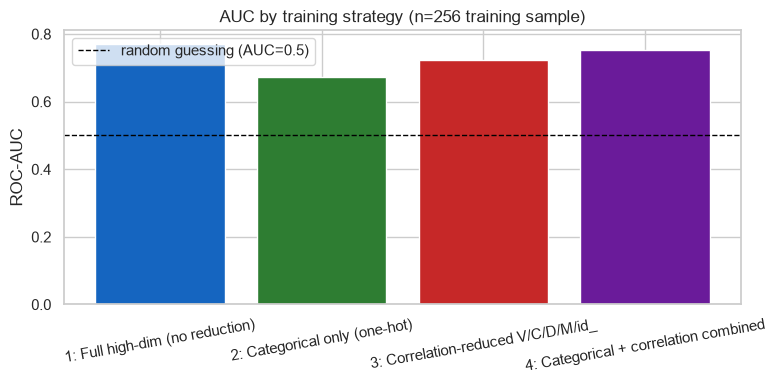

In [35]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#1565C0", "#2E7D32", "#C62828", "#6A1B9A"]
ax.bar(comparison["strategy"], comparison["auc"], color=colors)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1, label="random guessing (AUC=0.5)")
ax.set_ylabel("ROC-AUC")
ax.set_title(f"AUC by training strategy (n={TRAIN_SAMPLE_SIZE} training sample)")
ax.tick_params(axis="x", rotation=10)
ax.legend()
plt.tight_layout()
plt.show()


**Findings:** ranked by AUC — **Strategy 1 (0.7719, 419 features) > Strategy 4 (0.7527,
109 features) > Strategy 3 (0.7235, 30 features) > Strategy 2 (0.6732, 79 features)**.
The full, unreduced feature set still wins outright, but combining Strategies 2 and 3
closes most of the gap: Strategy 4 recovers 97.5% of Strategy 1's AUC from just 26% of
its features, and clearly outperforms both of its ingredients rather than landing
between them — concrete evidence that categorical rarity and numeric correlation with
fraud are complementary signals for Isolation Forest, not overlapping ones. Strategy 2
alone remains the weak point; its contribution only pays off once combined with
numeric information. For building on this further, **Strategy 4 is the most practical
choice**: it's close to Strategy 1's ceiling, every one of its 109 columns has a
documented reason for being included, and it's cheap to extend (e.g. raising Strategy
3's top-K, or loosening Strategy 2's one-hot cardinality cutoff) without starting over.


# Part 3: Deeper Look at Strategy 1 (Best-Performing)

Strategy 1 (full feature set, no reduction) had the highest AUC of the four strategies
(0.7719). This section visualizes how `model_s1`'s anomaly score varies across feature
space, to see where actual fraud sits relative to the score surface.

**Why not the earlier single-feature-pair contours:** those contours had a hidden
problem — to draw a continuous surface, a *new*, throwaway `IsolationForest` had to be
fit on just the 2 chosen axes, so the color was never really Strategy 1's score, only a
toy 2-feature model's opinion. This section fixes that by decoupling the two things a
contour needs: **color comes from `model_s1`'s real score**, computed on the full
419-feature `X1` (already available as `scores_s1`); **position comes from a 2D UMAP
layout** of those same 419 features, used only to place points on the page — no
surrogate model is fit on the 2D coordinates. UMAP (nonlinear, neighborhood-preserving)
is used instead of PCA for the layout, since PCA's linear projection only captured
~25% of variance earlier and distorted the local structure Isolation Forest actually
responds to.


## Anomaly Score Surface (UMAP Layout, Full 419-Feature Score)

Steps:

1. Draw a random subsample for visualization (UMAP on the full 590,540 rows would be
   expensive and isn't necessary for a picture — this is diagnostics, not training).
2. Standardize, then pre-reduce with PCA to 50 components — UMAP's own documentation
   recommends this for very high-dimensional input, both for speed and because UMAP's
   nearest-neighbor search is more reliable in a less noisy, lower-dimensional space.
3. Fit UMAP on those 50 components to get a 2D layout.
4. Plot a hexbin surface (mean real anomaly score per hexagon) with KDE density
   contour lines on top (showing where the data actually concentrates), and the
   withheld fraud points marked individually.


In [36]:
N_VIZ = 30000
rng_viz = np.random.default_rng(RNG_SEED)
viz_idx = rng_viz.choice(df.index, size=N_VIZ, replace=False)

X1_scaled_viz = StandardScaler().fit_transform(X1.loc[viz_idx])
pca_pre = PCA(n_components=50, random_state=RNG_SEED)
X1_pca50 = pca_pre.fit_transform(X1_scaled_viz)
print(f"Visualization subsample: {N_VIZ:,} rows")
print(f"PCA pre-reduction: 419 -> 50 components, "
      f"explaining {pca_pre.explained_variance_ratio_.sum() * 100:.1f}% of variance")


Visualization subsample: 30,000 rows
PCA pre-reduction: 419 -> 50 components, explaining 80.9% of variance


In [37]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="euclidean", random_state=RNG_SEED)
embedding = reducer.fit_transform(X1_pca50)
print(f"UMAP embedding shape: {embedding.shape}")


/opt/homebrew/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embedding shape: (30000, 2)


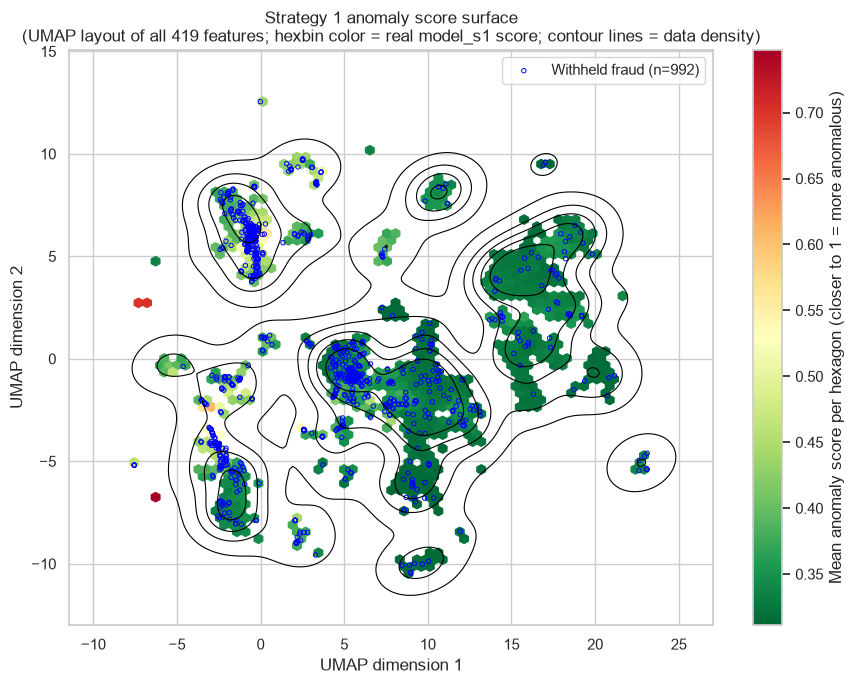

In [38]:
viz_scores = scores_s1[viz_idx]  # real Strategy 1 anomaly scores, full 419-feature model
viz_fraud = df.loc[viz_idx, "isFraud"].values

fig, ax = plt.subplots(figsize=(9, 7))
hb = ax.hexbin(embedding[:, 0], embedding[:, 1], C=viz_scores, reduce_C_function=np.mean,
               gridsize=60, cmap="RdYlGn_r", mincnt=5)
plt.colorbar(hb, ax=ax, label="Mean anomaly score per hexagon (closer to 1 = more anomalous)")

sns.kdeplot(x=embedding[:, 0], y=embedding[:, 1], levels=6, color="black", linewidths=0.8, ax=ax)

fraud_mask = viz_fraud == 1
ax.scatter(embedding[fraud_mask, 0], embedding[fraud_mask, 1], s=10, facecolors="none",
           edgecolors="blue", linewidths=0.7, label=f"Withheld fraud (n={fraud_mask.sum()})")

ax.set_xlabel("UMAP dimension 1")
ax.set_ylabel("UMAP dimension 2")
ax.set_title("Strategy 1 anomaly score surface\n"
              "(UMAP layout of all 419 features; hexbin color = real model_s1 score; "
              "contour lines = data density)")
ax.legend(loc="best")
plt.tight_layout()
plt.show()


**Findings:** the PCA pre-reduction step alone captured **80.9%** of variance in 50
components (vs. 25.3% from the earlier 2-component PCA), so UMAP is working from a much
more faithful representation of the full 419-feature space than the old contours were.

UMAP splits the 30,000-point sample into several distinct clusters/islands rather than
one continuous cloud — expected UMAP behavior, so the *shapes* shouldn't be
over-interpreted, but the *coloring* is informative since it reflects `model_s1`'s real
score. The overwhelming majority of hexagons across every cluster are green
(mean score ~0.30-0.40) — most transactions look structurally unremarkable to the model
regardless of which cluster they fall in. A small number of hexagons stand out sharply:
two tiny islands near (-7, 3) and (-7, -7) score ~0.70+ (deep red) — these are small,
structurally distinct groups of points that both UMAP's neighborhood-preserving layout
*and* the real high-dimensional model agree are unusual, which is a reassuring
consistency check between the two independent methods.

The 992 withheld fraud points (3.3% of this sample, close to the 3.5% base rate) are
scattered across nearly every cluster, including the largest, greenest ones — they do
**not** concentrate in or near the red outlier islands. This is the clearest picture
yet of what the AUC (0.77) already implied: Isolation Forest's highest-confidence
anomalies are small groups of genuinely rare transactions, but most actual fraud blends
into the same clusters as normal transactions rather than standing out structurally.
That's a real limitation of an unsupervised approach built only on isolation/rarity —
and unlike the single-feature-pair contours this replaces, it's now backed by the
model's actual 419-feature score rather than a 2-feature stand-in.


# Part 4: Sample-Size Scalability for Strategy 1

Strategies 1-4 were all trained at a fixed n=256 for a fair comparison between feature
sets. This section asks a different question for Strategy 1 specifically (the
best-performing feature set): **how do AUC and computation time change with the
training sample size**, and what's the best size to use?

**Setup**

- Sample sizes: powers of 4, from `4` up through the full dataset (`4, 16, 64, 256,
  1,024, 4,096, 16,384, 65,536, 262,144`, then the full 590,540 rows).
- Each size is fit 3 times (random `IsolationForest(random_state=RNG_SEED + repeat)`,
  a fresh random training subsample each repeat) and timing is reported as mean ± std,
  since timing has run-to-run noise.
- Every fit uses Strategy 1's feature matrix `X1` and is scored against the full
  dataset (`X1`, `y`) — same evaluation convention as Strategies 1-4, no held-out split.
- AUC and (fit + score) time are plotted together on one chart, sample size on a log
  x-axis, with AUC on a linear left axis and time on a log right axis (time spans
  several orders of magnitude across this range; AUC doesn't).


## Benchmark

In [39]:
sizes = []
s = 4
while s < len(df):
    sizes.append(s)
    s *= 4
sizes.append(len(df))
N_REPEATS = 3
print(f"Sample sizes (powers of 4, capped at the full dataset): {sizes}")


Sample sizes (powers of 4, capped at the full dataset): [4, 16, 64, 256, 1024, 4096, 16384, 65536, 262144, 590540]


In [40]:
results = []
rng_scale = np.random.default_rng(RNG_SEED)

for size in sizes:
    for repeat in range(N_REPEATS):
        sample_idx = rng_scale.choice(df.index, size=size, replace=False)
        X_train = X1.loc[sample_idx]

        t0 = time.perf_counter()
        model = IsolationForest(random_state=RNG_SEED + repeat)
        model.fit(X_train)
        fit_time = time.perf_counter() - t0

        t0 = time.perf_counter()
        scores = paper_anomaly_score(model, X1)
        score_time = time.perf_counter() - t0

        auc = roc_auc_score(y, scores)
        results.append({"size": size, "repeat": repeat, "fit_time": fit_time,
                         "score_time": score_time, "total_time": fit_time + score_time,
                         "auc": auc})

results_df = pd.DataFrame(results)
summary = results_df.groupby("size").agg(
    auc_mean=("auc", "mean"), auc_std=("auc", "std"),
    fit_time_mean=("fit_time", "mean"), fit_time_std=("fit_time", "std"),
    total_time_mean=("total_time", "mean"), total_time_std=("total_time", "std"),
).reset_index()
summary


,size,auc_mean,auc_std,fit_time_mean,fit_time_std,total_time_mean,total_time_std
0,4,0.620870,0.123354,0.077866,0.001101,3.268359,0.403014
1,16,0.732311,0.011260,0.078290,0.000518,3.126474,0.105543
2,64,0.760997,0.007898,0.079012,0.000540,3.829144,0.233544
3,256,0.762780,0.005470,0.086302,0.001417,4.106699,0.369813
4,1024,0.766091,0.005426,0.088227,0.002230,3.606447,0.058306
5,4096,0.764616,0.002577,0.096204,0.001263,3.504364,0.171898
6,16384,0.768291,0.003747,0.130539,0.003776,3.491501,0.118488
7,65536,0.769147,0.005058,0.250522,0.042015,3.662021,0.093921
8,262144,0.765025,0.003451,1.352588,0.077922,5.228610,0.217423
9,590540,0.766688,0.003952,2.732991,0.094961,6.613385,0.349159


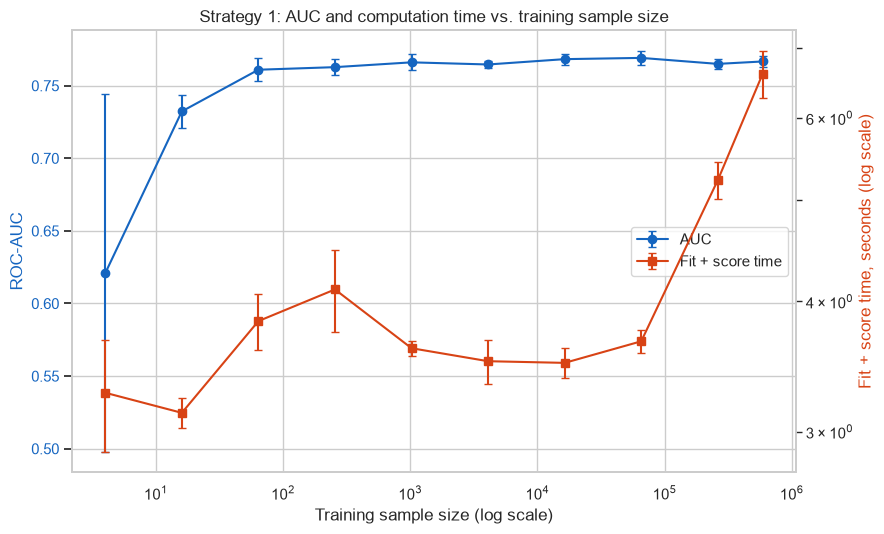

In [41]:
fig, ax1 = plt.subplots(figsize=(9, 5.5))

ax1.errorbar(summary["size"], summary["auc_mean"], yerr=summary["auc_std"],
             marker="o", color="#1565C0", capsize=3, label="AUC")
ax1.set_xscale("log")
ax1.set_xlabel("Training sample size (log scale)")
ax1.set_ylabel("ROC-AUC", color="#1565C0")
ax1.tick_params(axis="y", labelcolor="#1565C0")

ax2 = ax1.twinx()
ax2.errorbar(summary["size"], summary["total_time_mean"], yerr=summary["total_time_std"],
             marker="s", color="#D84315", capsize=3, label="Fit + score time")
ax2.set_yscale("log")
ax2.set_ylabel("Fit + score time, seconds (log scale)", color="#D84315")
ax2.tick_params(axis="y", labelcolor="#D84315")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

ax1.set_title("Strategy 1: AUC and computation time vs. training sample size")
plt.tight_layout()
plt.show()


## Identifying the Best Sample Size

Rule: find the best AUC observed across all sizes, then pick the **smallest** sample
size whose AUC is within 1% of that best — i.e. the point where growing the sample
stops meaningfully improving AUC but keeps costing more time.


In [42]:
AUC_TOLERANCE = 0.99  # "as good as the best" = within 1% of the best observed AUC

max_row = summary.loc[summary["auc_mean"].idxmax()]
best_auc = max_row["auc_mean"]

qualifying = summary[summary["auc_mean"] >= best_auc * AUC_TOLERANCE]
best_size = int(qualifying["size"].min())
best_row = summary[summary["size"] == best_size].iloc[0]
full_row = summary[summary["size"] == len(df)].iloc[0]

print(f"Best AUC observed: {best_auc:.4f} at size {int(max_row['size']):,} "
      f"(fit+score time={max_row['total_time_mean']:.3f}s)")
print(f"Smallest size within {(1 - AUC_TOLERANCE) * 100:.0f}% of best AUC: "
      f"{best_size:,} (AUC={best_row['auc_mean']:.4f}, "
      f"fit+score time={best_row['total_time_mean']:.3f}s)")
print(f"Full-size ({len(df):,}) fit+score time for comparison: "
      f"{full_row['total_time_mean']:.3f}s")
print(f"Speedup at best_size vs. full size: "
      f"{full_row['total_time_mean'] / best_row['total_time_mean']:.1f}x")


Best AUC observed: 0.7691 at size 65,536 (fit+score time=3.662s)
Smallest size within 1% of best AUC: 256 (AUC=0.7628, fit+score time=4.107s)
Full-size (590,540) fit+score time for comparison: 6.613s
Speedup at best_size vs. full size: 1.6x


**Findings:** AUC rises sharply and noisily at the smallest sizes — n=4 averages just
0.621 with a huge std (±0.123, meaning individual repeats swing wildly depending on
which 4 rows get sampled) — then climbs through n=16 (0.732) and n=64 (0.761), and from
n=64 onward it's essentially flat, oscillating in a tight 0.763-0.769 band all the way
to the full dataset (0.767). The peak mean AUC (0.7691) happens at n=65,536, but that's
within noise of several smaller sizes, not a real peak. The **1%-tolerance rule picks
`best_size = 256`** — which happens to be exactly the training size used for Strategies
1-4 throughout this notebook, a nice independent confirmation that n=256 wasn't an
arbitrary choice.
